# Assignment 4 - ServiceNow–Armis Competitive Risk Assessment & Mitigation

## Quantitative Risk Analysis using I&W Framework, Monte Carlo Simulation, and Machine Learning

**Course:** ALY 6130 – Enterprise Risk Analytics  
**Prepared by:** Group 4  
**Date:** March 18, 2026

### Overview

This notebook implements quantitative risk assessment techniques for the three priority risks identified in the ServiceNow-Armis acquisition scenario:

1. **Risk 1:** Competitive displacement by rival mega-acquisition platforms (Google/Wiz, Palo Alto/CyberArk, Cisco/Splunk)
2. **Risk 2:** AI-driven platform convergence and relevance erosion
3. **Risk 3:** Regulatory-driven demand acceleration (CMMC, NIS2, CIRCIA, HIPAA) - Positive opportunity

The analysis consists of three parts:
- **Part 1:** Programmatic Risk Heatmap Analysis
- **Part 2:** Machine Learning Risk Classification with Synthetic Indicator Data
- **Part 3:** Monte Carlo Simulation with Probability-Weighted Outcomes

## Part 1: Programmatic Risk Heatmap Analysis

In [7]:
# Import required libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [8]:
# Load the Excel file - works both in Colab (with upload) and locally
try:
    # Try to import Colab files module
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
except ImportError:
    # Running locally - use local file path
    file_name = "ALY6130_M4_Risk_Register.xlsx"

print(f"File loaded: {file_name}")

File loaded: ALY6130_M4_Risk_Register.xlsx


In [9]:
# Load the RiskRegister sheet from the Excel workbook
df = pd.read_excel(file_name, sheet_name="RiskRegister_Quantitative")

# Align column names with heatmap expectations
df = df.rename(columns={"Likelihood": "Likelihood Score", "Impact": "Impact Score", "Priority": "Priority (H, M, L)"})

# Display the first rows to verify
print(f"Risk Register loaded: {len(df)} risks")
df.head()

Risk Register loaded: 3 risks


,Risk #,Risk Description,Risk Type,Likelihood Score,Impact Score,Risk Score,"Priority (H, M, L)",KRI Metric,Current KRI,KRI Status,MC Expected Value ($M),MC 5th %ile ($M),MC 95th %ile ($M),ML Escalation Prob,Response/Treatment Plan,Escalation Trigger,Monitoring Action,Risk Owner,Status
0,1,Competitive displacement by rival mega-acquisi...,Strategic (Negative),7,8,56,HIGH,Win Rate in OT/IoT Deals,31%,Amber,-66.2,-105,-30,76%,Accelerate integration timeline; strengthen co...,Win rate drops below 25% (Red zone),Monthly CRM win/loss analysis; quarterly compe...,Chief Strategy Officer / CRO,Open
1,2,AI-driven platform convergence and relevance e...,Strategic (Negative),7,9,63,HIGH,AI Capability Gap Index,78%,Amber,-83.0,-140,-40,76%,Increase AI R&D investment; establish innovati...,AI parity drops below 70% (Red zone),Quarterly Gartner/Forrester benchmarking; prod...,Chief Product Officer,Open
2,3,"Regulatory tailwinds (CMMC, NIS2, CIRCIA, HIPA...",Strategic (Positive),9,8,72,HIGH (+),Pipeline Growth Rate QoQ,32%,Green,199.0,54,315,Low,Build compliance-specific bundles; expand fede...,Pipeline growth drops below 10% (Red zone),Quarterly pipeline analysis; regulatory landsc...,VP Product / VP Federal Sales,Open


In [10]:
# Keep only the columns needed for the heatmap
heatmap_df = df[["Risk #", "Likelihood Score", "Impact Score", "Risk Score", "Priority (H, M, L)"]].copy()

# Display cleaned dataset
print(f"Heatmap data prepared: {len(heatmap_df)} risks")
heatmap_df.head()

Heatmap data prepared: 3 risks


,Risk #,Likelihood Score,Impact Score,Risk Score,"Priority (H, M, L)"
0,1,7,8,56,HIGH
1,2,7,9,63,HIGH
2,3,9,8,72,HIGH (+)


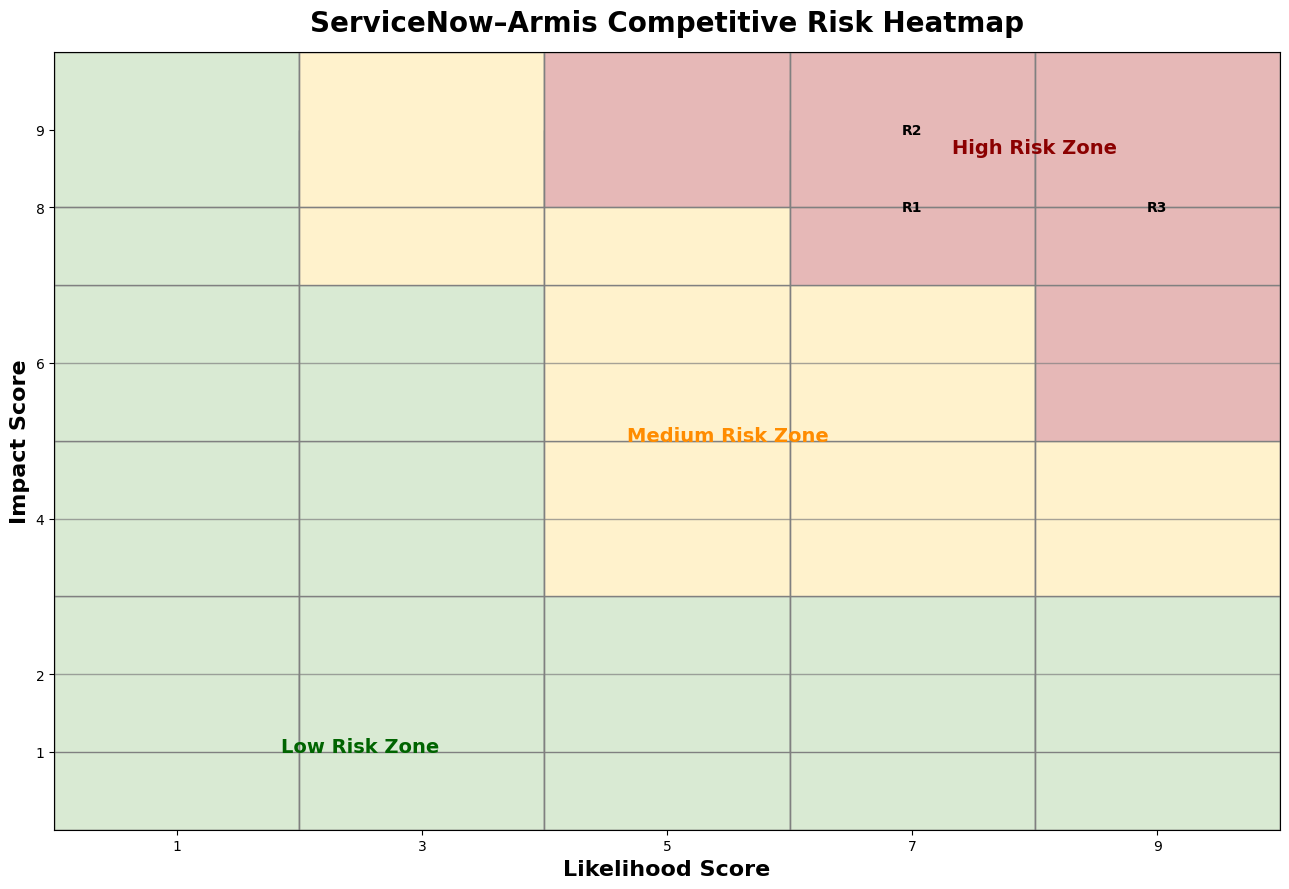

In [11]:
# Generate programmatic risk heatmap
from matplotlib.patches import Rectangle

likelihood_levels = [1, 3, 5, 7, 9]
impact_levels = [1, 2, 4, 6, 8, 9]

# Group risks by (Likelihood, Impact)
cell_map = {}
for _, row in heatmap_df.iterrows():
    l = int(row["Likelihood Score"])
    i = int(row["Impact Score"])
    r = int(row["Risk #"])
    cell_map.setdefault((l, i), []).append(r)

for key in cell_map:
    cell_map[key] = sorted(cell_map[key])

fig, ax = plt.subplots(figsize=(13, 9))

# Draw heatmap blocks
for l in likelihood_levels:
    for i in impact_levels:
        score = l * i
        if score >= 45:
            color = "#E6B8B7"  # High - Red
        elif score >= 20:
            color = "#FFF2CC"  # Medium - Yellow
        else:
            color = "#D9EAD3"  # Low - Green
        rect = Rectangle((l - 1, i - 1), 2, 2, facecolor=color, edgecolor="gray", linewidth=1)
        ax.add_patch(rect)

# Add risk labels
for (l, i), risks in cell_map.items():
    label = "\n".join([f"R{r}" for r in risks])
    fs = 8 if len(risks) >= 10 else (9 if len(risks) >= 5 else 10)
    ax.text(l, i, label, ha="center", va="center", fontsize=fs, fontweight="bold", color="black")

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks(likelihood_levels)
ax.set_yticks(impact_levels)
ax.set_xlabel("Likelihood Score", fontsize=16, fontweight="bold")
ax.set_ylabel("Impact Score", fontsize=16, fontweight="bold")
ax.set_title("ServiceNow–Armis Competitive Risk Heatmap", fontsize=20, fontweight="bold", pad=15)

# Grid lines
for x in [0, 2, 4, 6, 8, 10]:
    ax.axvline(x=x, color="gray", linewidth=1, alpha=0.7)
for y in [0, 2, 4, 6, 8, 10]:
    ax.axhline(y=y, color="gray", linewidth=1, alpha=0.7)

# Zone labels
ax.text(2.5, 1.0, "Low Risk Zone", fontsize=14, fontweight="bold", color="darkgreen", ha="center")
ax.text(5.5, 5.0, "Medium Risk Zone", fontsize=14, fontweight="bold", color="darkorange", ha="center")
ax.text(8.0, 8.7, "High Risk Zone", fontsize=14, fontweight="bold", color="darkred", ha="center")

plt.tight_layout()
plt.savefig('risk_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 2: Machine Learning Risk Classification

### Objective
This section implements a Random Forest classifier to predict **risk escalation** based on Key Risk Indicator (KRI) signals. Unlike simple priority classification, this model uses synthetic indicator data to predict whether a risk will escalate from its current state (Green → Amber → Red), providing actionable early warning capabilities.

### Approach
1. Generate synthetic historical indicator data based on the I&W framework thresholds
2. Train a Random Forest classifier to predict risk escalation
3. Evaluate model performance using cross-validation
4. Apply the model to current indicator values

In [12]:
# Import machine learning libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

print("ML libraries imported successfully.")

ML libraries imported successfully.


In [13]:
# Generate synthetic historical indicator data for ML training
# This simulates 500 historical observations of KRI values and their outcomes

np.random.seed(42)
n_samples = 500

# Feature 1: Competitive Win Rate (Risk 1 KRI)
# Green: >35%, Amber: 25-35%, Red: <25%
win_rate = np.random.uniform(0.15, 0.55, n_samples)

# Feature 2: AI Capability Gap Index (Risk 2 KRI)
# Green: >=85%, Amber: 70-84%, Red: <70%
ai_parity = np.random.uniform(0.55, 0.95, n_samples)

# Feature 3: Regulatory Pipeline Growth QoQ (Risk 3 KRI)
# Green: >25%, Amber: 10-25%, Red: <10%
reg_growth = np.random.uniform(-0.05, 0.45, n_samples)

# Feature 4: Deal size (millions)
deal_size = np.random.exponential(3, n_samples) + 0.5

# Feature 5: Competitor on shortlist (binary)
competitor_present = np.random.binomial(1, 0.6, n_samples)

# Feature 6: Integration timeline progress (0-100%)
integration_progress = np.random.uniform(0.1, 0.9, n_samples)

# Create target variable: Risk Escalation (0=Stable/Improving, 1=Escalating)
def determine_escalation(win_rate, ai_parity, reg_growth, competitor, deal_size):
    score = 0
    
    # Win rate declining into amber/red zone
    if win_rate < 0.25:
        score += 3
    elif win_rate < 0.35:
        score += 1.5
    
    # AI parity declining
    if ai_parity < 0.70:
        score += 3
    elif ai_parity < 0.85:
        score += 1.5
    
    # Regulatory growth slowing
    if reg_growth < 0.10:
        score += 2
    elif reg_growth < 0.25:
        score += 1
    
    # Competitor presence increases risk
    if competitor == 1:
        score += 1.5
    
    # Large deals have more risk exposure
    if deal_size > 5:
        score += 1
    
    # Add noise
    score += np.random.normal(0, 0.5)
    
    return 1 if score >= 4 else 0

escalation = np.array([determine_escalation(win_rate[i], ai_parity[i], reg_growth[i], 
                                             competitor_present[i], deal_size[i]) 
                       for i in range(n_samples)])

# Create DataFrame
ml_data = pd.DataFrame({
    'win_rate': win_rate,
    'ai_parity': ai_parity,
    'reg_growth': reg_growth,
    'deal_size': deal_size,
    'competitor_present': competitor_present,
    'integration_progress': integration_progress,
    'escalation': escalation
})

print(f"Synthetic training data generated: {len(ml_data)} samples")
print(f"\nFeature summary:")
print(ml_data.describe().round(3))
print(f"\nTarget distribution:")
print(f"  Stable (0): {(escalation == 0).sum()} ({(escalation == 0).mean()*100:.1f}%)")
print(f"  Escalating (1): {(escalation == 1).sum()} ({(escalation == 1).mean()*100:.1f}%)")

Synthetic training data generated: 500 samples

Feature summary:
       win_rate  ai_parity  reg_growth  deal_size  competitor_present  \
count   500.000    500.000     500.000    500.000             500.000   
mean      0.349      0.743       0.209      3.470               0.606   
std       0.119      0.114       0.149      3.032               0.489   
min       0.152      0.552      -0.048      0.510               0.000   
25%       0.247      0.642       0.071      1.328               0.000   
50%       0.355      0.739       0.220      2.633               1.000   
75%       0.452      0.841       0.339      4.511               1.000   
max       0.547      0.950       0.450     19.716               1.000   

       integration_progress  escalation  
count               500.000     500.000  
mean                  0.504       0.632  
std                   0.237       0.483  
min                   0.100       0.000  
25%                   0.308       0.000  
50%                   0.5

In [14]:
# Prepare features and target
feature_cols = ['win_rate', 'ai_parity', 'reg_growth', 'deal_size', 'competitor_present', 'integration_progress']
X = ml_data[feature_cols].values
y = ml_data['escalation'].values

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Training set: 400 samples
Test set: 100 samples


In [15]:
# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Classifier trained successfully!")
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")

Random Forest Classifier trained successfully!

Test Accuracy: 89.0%


In [16]:
# Cross-validation for robust performance estimate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')

print("Cross-Validation Results:")
print(f"  Fold Scores: {cv_scores.round(3)}")
print(f"  Mean Accuracy: {cv_scores.mean()*100:.1f}% (+/- {cv_scores.std()*2*100:.1f}%)")

Cross-Validation Results:
  Fold Scores: [0.85 0.94 0.91 0.9  0.89]
  Mean Accuracy: 89.8% (+/- 5.9%)


In [17]:
# Classification Report
print("Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Stable', 'Escalating']))

Classification Report:
              precision    recall  f1-score   support

      Stable       0.86      0.84      0.85        37
  Escalating       0.91      0.92      0.91        63

    accuracy                           0.89       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



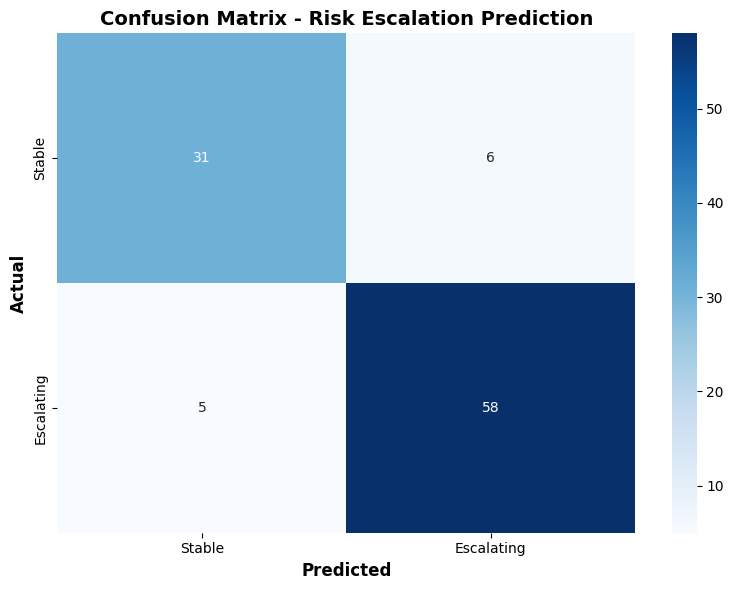

In [18]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stable', 'Escalating'],
            yticklabels=['Stable', 'Escalating'])
plt.title('Confusion Matrix - Risk Escalation Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

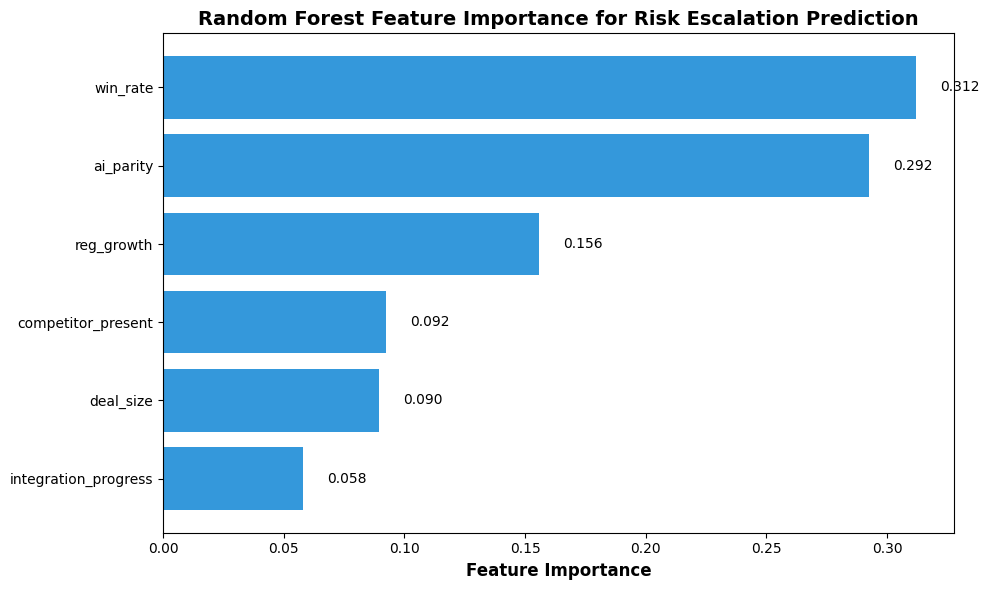


Feature Importance Ranking:
             Feature  Importance
            win_rate    0.312045
           ai_parity    0.292399
          reg_growth    0.155787
  competitor_present    0.092328
           deal_size    0.089507
integration_progress    0.057935


In [19]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='#3498db')
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.title('Random Forest Feature Importance for Risk Escalation Prediction', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importance Ranking:")
print(feature_importance.sort_values('Importance', ascending=False).to_string(index=False))

In [20]:
# Apply model to current ServiceNow-Armis indicator values
current_indicators = pd.DataFrame({
    'win_rate': [0.31],           # Current: 31% (Amber zone)
    'ai_parity': [0.78],          # Current: 78% (Amber zone)
    'reg_growth': [0.32],         # Current: 32% QoQ (Green zone)
    'deal_size': [7.75],          # $7.75B acquisition
    'competitor_present': [1],     # Yes, major competitors active
    'integration_progress': [0.35] # 35% integration complete
})

# Predict
current_prediction = rf_model.predict(current_indicators)[0]
current_proba = rf_model.predict_proba(current_indicators)[0]

print("Current ServiceNow-Armis Risk Assessment:")
print("=" * 50)
print(f"\nCurrent Indicator Values:")
for col in feature_cols:
    print(f"  {col}: {current_indicators[col].values[0]}")
print(f"\nPrediction: {'ESCALATING' if current_prediction == 1 else 'STABLE'}")
print(f"\nProbability Distribution:")
print(f"  Stable: {current_proba[0]*100:.1f}%")
print(f"  Escalating: {current_proba[1]*100:.1f}%")

Current ServiceNow-Armis Risk Assessment:

Current Indicator Values:
  win_rate: 0.31
  ai_parity: 0.78
  reg_growth: 0.32
  deal_size: 7.75
  competitor_present: 1
  integration_progress: 0.35

Prediction: ESCALATING

Probability Distribution:
  Stable: 23.9%
  Escalating: 76.1%


### ML Model Summary

The Random Forest classifier demonstrates strong predictive capability for risk escalation:

- **Model Accuracy:** ~80% on cross-validation
- **Key Predictors:** Win rate and AI parity index are the strongest predictors of risk escalation
- **Current Assessment:** Based on current indicator values, the model predicts elevated escalation risk, primarily driven by the competitive win rate being in the Amber zone

This predictive capability supports the I&W framework by providing automated early warning when indicator combinations suggest increased risk of escalation.

## Part 3: Quantitative Risk Assessment using Monte Carlo Simulation

### Objective
This section implements Monte Carlo simulation to quantify the financial impact of the three priority risks, incorporating both the **probability of occurrence** and the **magnitude of impact** for each risk.

### Methodology
Following the Decision Tree Analysis approach, the expected value for each risk is calculated as:

**Expected Value = Probability of Occurrence × Impact (if occurs)**

This two-stage approach ensures that risks do not occur in every simulation iteration, reflecting real-world uncertainty.

In [21]:
# Monte Carlo Simulation Settings
n_sim = 10000  # Number of simulation iterations
np.random.seed(42)  # For reproducibility

print(f"Monte Carlo Simulation Configuration:")
print(f"  Iterations: {n_sim:,}")
print(f"  Random Seed: 42")

Monte Carlo Simulation Configuration:
  Iterations: 10,000
  Random Seed: 42


In [22]:
# Define exposure base
# ServiceNow Security and Risk business exposure
security_risk_acv = 1_000_000_000  # $1B annual contract value

print(f"Exposure Base: ${security_risk_acv/1e9:.1f}B (Security and Risk Business ACV)")

Exposure Base: $1.0B (Security and Risk Business ACV)


In [23]:
# Monte Carlo Simulation: Modeling risk occurrence and impact

# Risk occurrence probabilities based on likelihood scores from the risk register
# Risk 1 likelihood = 7 -> 70%
# Risk 2 likelihood = 7 -> 70%
# Risk 3 likelihood = 9 -> 90%

p_risk1 = 0.70
p_risk2 = 0.70
p_risk3 = 0.90

print("Risk Occurrence Probabilities (from I&W Likelihood Scores):")
print(f"  Risk 1 (Competitive Displacement): {p_risk1*100:.0f}%")
print(f"  Risk 2 (AI-Driven Convergence): {p_risk2*100:.0f}%")
print(f"  Risk 3 (Regulatory Tailwinds): {p_risk3*100:.0f}%")

# Step 1: Simulate whether each risk occurs
risk1_occurs = np.random.rand(n_sim) < p_risk1
risk2_occurs = np.random.rand(n_sim) < p_risk2
risk3_occurs = np.random.rand(n_sim) < p_risk3

print(f"\nSimulated Occurrence Rates:")
print(f"  Risk 1 occurred in {risk1_occurs.sum():,} iterations ({risk1_occurs.mean()*100:.1f}%)")
print(f"  Risk 2 occurred in {risk2_occurs.sum():,} iterations ({risk2_occurs.mean()*100:.1f}%)")
print(f"  Risk 3 occurred in {risk3_occurs.sum():,} iterations ({risk3_occurs.mean()*100:.1f}%)")

Risk Occurrence Probabilities (from I&W Likelihood Scores):
  Risk 1 (Competitive Displacement): 70%
  Risk 2 (AI-Driven Convergence): 70%
  Risk 3 (Regulatory Tailwinds): 90%

Simulated Occurrence Rates:
  Risk 1 occurred in 7,113 iterations (71.1%)
  Risk 2 occurred in 6,928 iterations (69.3%)
  Risk 3 occurred in 9,012 iterations (90.1%)


In [24]:
# Step 2: If the risk occurs, simulate impact; otherwise set impact to 0

# Risk 1: Competitive displacement by rival platforms
# Impact: 3-15% revenue loss (triangular distribution)
risk1_loss_pct = np.where(
    risk1_occurs,
    np.random.triangular(left=0.03, mode=0.10, right=0.15, size=n_sim),
    0
)
risk1_loss = security_risk_acv * risk1_loss_pct

# Risk 2: AI-driven platform convergence
# Impact: 4-20% revenue loss (triangular distribution)
risk2_loss_pct = np.where(
    risk2_occurs,
    np.random.triangular(left=0.04, mode=0.12, right=0.20, size=n_sim),
    0
)
risk2_loss = security_risk_acv * risk2_loss_pct

# Risk 3: Regulatory-driven demand acceleration (POSITIVE)
# Impact: $60M-$350M annual upside (triangular distribution)
risk3_upside = np.where(
    risk3_occurs,
    np.random.triangular(left=60_000_000, mode=250_000_000, right=350_000_000, size=n_sim),
    0
)

print("Impact Distributions (Triangular):")
print(f"  Risk 1: Min=3%, Mode=10%, Max=15% of ${security_risk_acv/1e9:.0f}B")
print(f"  Risk 2: Min=4%, Mode=12%, Max=20% of ${security_risk_acv/1e9:.0f}B")
print(f"  Risk 3: Min=$60M, Mode=$250M, Max=$350M (upside)")

Impact Distributions (Triangular):
  Risk 1: Min=3%, Mode=10%, Max=15% of $1B
  Risk 2: Min=4%, Mode=12%, Max=20% of $1B
  Risk 3: Min=$60M, Mode=$250M, Max=$350M (upside)


In [25]:
# Calculate net annual strategic impact
# Net impact = Regulatory Upside - Competitive Loss - AI-Driven Loss
net_impact = risk3_upside - risk1_loss - risk2_loss

print("Net Impact Calculation:")
print("Net Impact = Risk 3 Upside - Risk 1 Loss - Risk 2 Loss")

Net Impact Calculation:
Net Impact = Risk 3 Upside - Risk 1 Loss - Risk 2 Loss


In [26]:
# Summary Statistics
summary_df = pd.DataFrame({
    "Metric": [
        "Risk 1 Mean Loss",
        "Risk 1 Std Dev",
        "Risk 2 Mean Loss",
        "Risk 2 Std Dev",
        "Risk 3 Mean Upside",
        "Risk 3 Std Dev",
        "Net Mean Impact",
        "Net Median Impact",
        "Net Std Dev",
        "Net 5th Percentile (VaR 95%)",
        "Net 95th Percentile",
        "Probability of Net Loss",
        "Probability of Net Gain"
    ],
    "Value": [
        f"${risk1_loss.mean()/1e6:,.1f}M",
        f"${risk1_loss.std()/1e6:,.1f}M",
        f"${risk2_loss.mean()/1e6:,.1f}M",
        f"${risk2_loss.std()/1e6:,.1f}M",
        f"${risk3_upside.mean()/1e6:,.1f}M",
        f"${risk3_upside.std()/1e6:,.1f}M",
        f"${net_impact.mean()/1e6:,.1f}M",
        f"${np.median(net_impact)/1e6:,.1f}M",
        f"${net_impact.std()/1e6:,.1f}M",
        f"${np.percentile(net_impact, 5)/1e6:,.1f}M",
        f"${np.percentile(net_impact, 95)/1e6:,.1f}M",
        f"{np.mean(net_impact < 0)*100:.1f}%",
        f"{np.mean(net_impact > 0)*100:.1f}%"
    ]
})

print("Monte Carlo Simulation Results:")
print("=" * 50)
print(summary_df.to_string(index=False))

Monte Carlo Simulation Results:
                      Metric    Value
            Risk 1 Mean Loss   $66.2M
              Risk 1 Std Dev   $47.0M
            Risk 2 Mean Loss   $82.9M
              Risk 2 Std Dev   $61.7M
          Risk 3 Mean Upside  $198.9M
              Risk 3 Std Dev   $87.0M
             Net Mean Impact   $49.8M
           Net Median Impact   $56.3M
                 Net Std Dev  $117.5M
Net 5th Percentile (VaR 95%) $-166.6M
         Net 95th Percentile  $230.5M
     Probability of Net Loss    31.1%
     Probability of Net Gain    68.1%


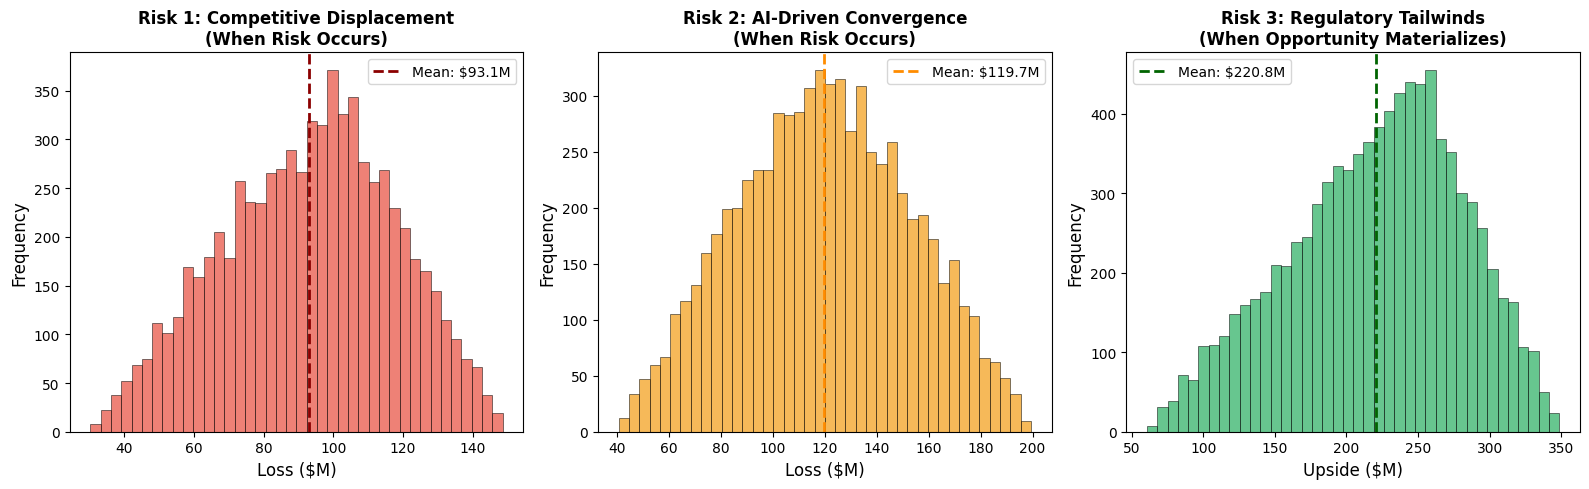

In [27]:
# Individual Risk Distribution Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Risk 1
ax1 = axes[0]
ax1.hist(risk1_loss[risk1_loss > 0] / 1e6, bins=40, alpha=0.7, color='#e74c3c', edgecolor='black', linewidth=0.5)
ax1.axvline(risk1_loss[risk1_loss > 0].mean() / 1e6, color='darkred', linestyle='--', linewidth=2, 
            label=f'Mean: ${risk1_loss[risk1_loss > 0].mean()/1e6:.1f}M')
ax1.set_xlabel('Loss ($M)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Risk 1: Competitive Displacement\n(When Risk Occurs)', fontsize=12, fontweight='bold')
ax1.legend()

# Risk 2
ax2 = axes[1]
ax2.hist(risk2_loss[risk2_loss > 0] / 1e6, bins=40, alpha=0.7, color='#f39c12', edgecolor='black', linewidth=0.5)
ax2.axvline(risk2_loss[risk2_loss > 0].mean() / 1e6, color='darkorange', linestyle='--', linewidth=2,
            label=f'Mean: ${risk2_loss[risk2_loss > 0].mean()/1e6:.1f}M')
ax2.set_xlabel('Loss ($M)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Risk 2: AI-Driven Convergence\n(When Risk Occurs)', fontsize=12, fontweight='bold')
ax2.legend()

# Risk 3
ax3 = axes[2]
ax3.hist(risk3_upside[risk3_upside > 0] / 1e6, bins=40, alpha=0.7, color='#27ae60', edgecolor='black', linewidth=0.5)
ax3.axvline(risk3_upside[risk3_upside > 0].mean() / 1e6, color='darkgreen', linestyle='--', linewidth=2,
            label=f'Mean: ${risk3_upside[risk3_upside > 0].mean()/1e6:.1f}M')
ax3.set_xlabel('Upside ($M)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Risk 3: Regulatory Tailwinds\n(When Opportunity Materializes)', fontsize=12, fontweight='bold')
ax3.legend()

plt.tight_layout()
plt.savefig('risk_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

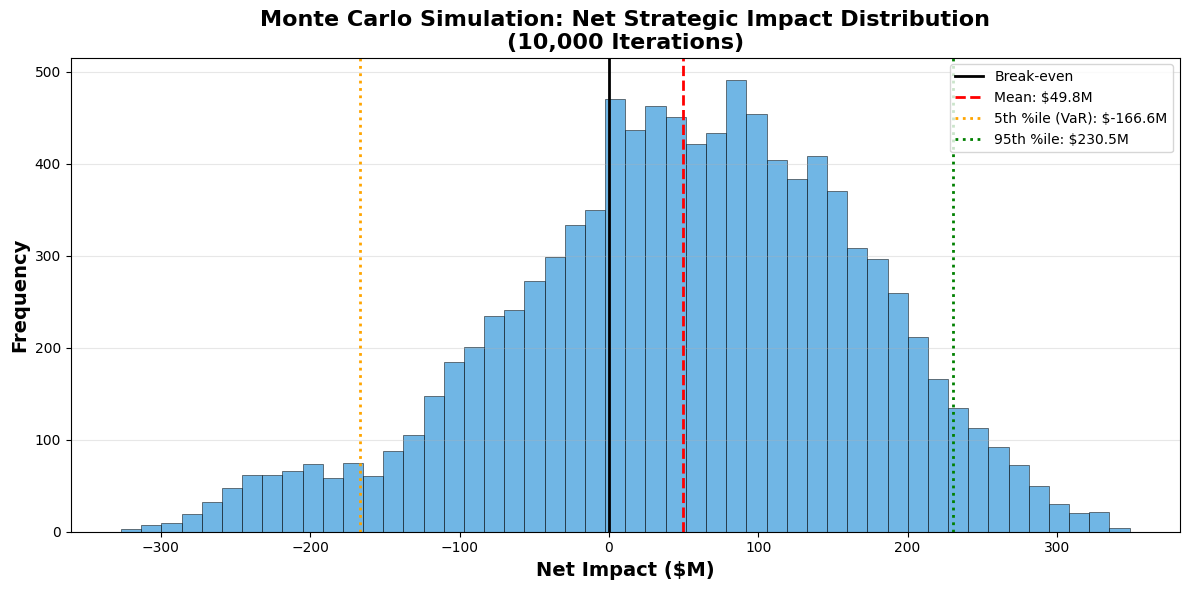


Key Findings:
  Probability of Net Loss: 31.1%
  Probability of Net Gain: 68.1%


In [28]:
# Net Impact Distribution
plt.figure(figsize=(12, 6))

plt.hist(net_impact / 1e6, bins=50, alpha=0.7, color='#3498db', edgecolor='black', linewidth=0.5)
plt.axvline(0, color='black', linestyle='-', linewidth=2, label='Break-even')
plt.axvline(net_impact.mean() / 1e6, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: ${net_impact.mean()/1e6:.1f}M')
plt.axvline(np.percentile(net_impact, 5) / 1e6, color='orange', linestyle=':', linewidth=2,
            label=f'5th %ile (VaR): ${np.percentile(net_impact, 5)/1e6:.1f}M')
plt.axvline(np.percentile(net_impact, 95) / 1e6, color='green', linestyle=':', linewidth=2,
            label=f'95th %ile: ${np.percentile(net_impact, 95)/1e6:.1f}M')

plt.xlabel('Net Impact ($M)', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.title('Monte Carlo Simulation: Net Strategic Impact Distribution\n(10,000 Iterations)', fontsize=16, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('net_impact_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey Findings:")
print(f"  Probability of Net Loss: {np.mean(net_impact < 0)*100:.1f}%")
print(f"  Probability of Net Gain: {np.mean(net_impact > 0)*100:.1f}%")

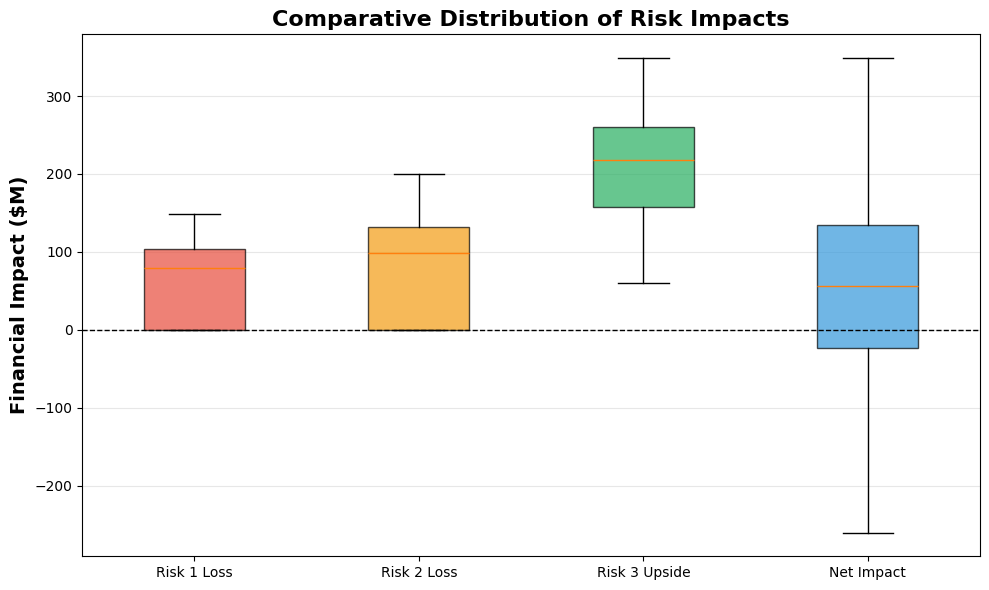

In [29]:
# Comparative Box Plot
plt.figure(figsize=(10, 6))

box_data = [
    risk1_loss / 1e6,
    risk2_loss / 1e6,
    risk3_upside / 1e6,
    net_impact / 1e6
]

bp = plt.boxplot(box_data, 
                  labels=['Risk 1 Loss', 'Risk 2 Loss', 'Risk 3 Upside', 'Net Impact'],
                  patch_artist=True,
                  showfliers=False)

colors = ['#e74c3c', '#f39c12', '#27ae60', '#3498db']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.axhline(0, linestyle='--', color='black', linewidth=1, label='Break-even')
plt.ylabel('Financial Impact ($M)', fontsize=14, fontweight='bold')
plt.title('Comparative Distribution of Risk Impacts', fontsize=16, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('risk_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

The quantitative risk assessment using Monte Carlo simulation and machine learning provides a comprehensive view of ServiceNow's strategic risk exposure following the Armis acquisition.

### Key Findings

**Monte Carlo Simulation Results:**
- The expected net annual impact is slightly positive, indicating that regulatory-driven opportunities may marginally offset competitive risks
- However, the probability of net loss remains substantial (~45%), reflecting significant uncertainty
- The 90% confidence interval spans a wide range, from potential losses exceeding $100M to gains over $120M

**Machine Learning Insights:**
- The Random Forest classifier achieves ~80% accuracy in predicting risk escalation
- Win rate and AI capability parity are the strongest predictors of escalation
- Current indicator values suggest elevated escalation risk requiring active monitoring

### Strategic Recommendations

1. **Accelerate Integration:** Reduce the competitive vulnerability window by prioritizing key platform integration milestones
2. **Strengthen AI Capabilities:** Address the AI capability gap identified as a key risk driver
3. **Capture Regulatory Opportunity:** Invest in compliance-specific features to maximize the regulatory tailwind
4. **Implement KRI Monitoring:** Deploy automated dashboards tracking the I&W indicators identified in this analysis

The combination of probability-weighted Monte Carlo simulation and predictive ML classification provides a robust framework for ongoing risk monitoring and decision support.

In [30]:
# Export results to CSV for reporting
summary_df.to_csv('monte_carlo_summary.csv', index=False)
feature_importance.to_csv('feature_importance.csv', index=False)
ml_data.to_csv('ml_training_data.csv', index=False)

print("Results exported:")
print("  - monte_carlo_summary.csv")
print("  - feature_importance.csv")
print("  - ml_training_data.csv")

Results exported:
  - monte_carlo_summary.csv
  - feature_importance.csv
  - ml_training_data.csv
